  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (to

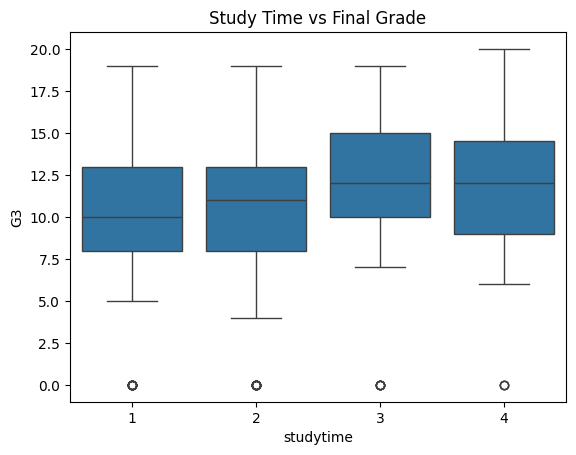

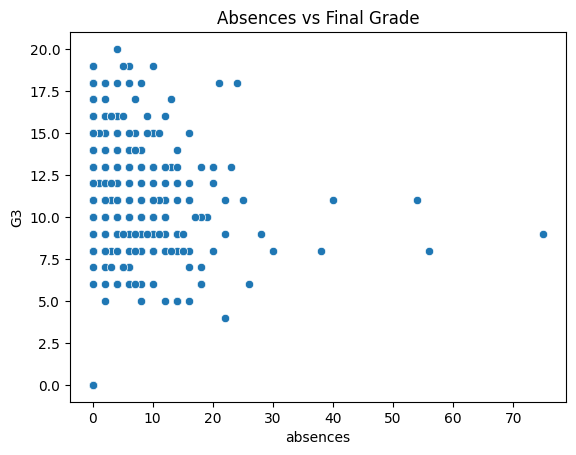

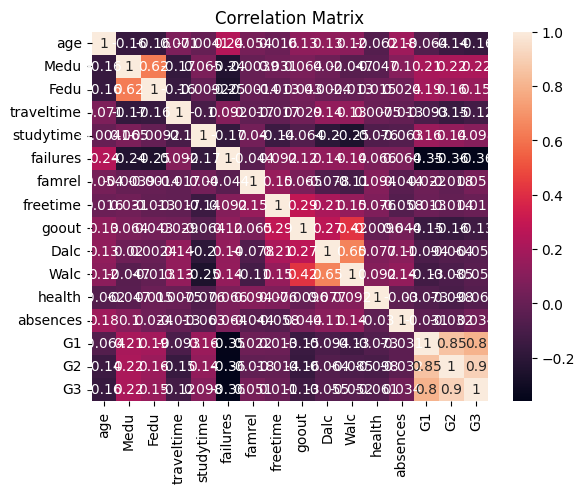

cluster
0    199
1    154
2     42
Name: count, dtype: int64
         studytime  absences  failures         G3
cluster                                          
0         2.075377  6.989950  0.150754   8.432161
1         2.136364  4.292208  0.084416  14.396104
2         1.476190  4.833333  2.119048   5.214286
   cluster     learning_profile
0        0  Consistent Learners
1        0  Consistent Learners
2        2  Struggling Students
3        1   Irregular Learners
4        0  Consistent Learners
Logistic Regression Accuracy:
0.9493670886075949
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        27
           1       0.98      0.94      0.96        52

    accuracy                           0.95        79
   macro avg       0.94      0.95      0.94        79
weighted avg       0.95      0.95      0.95        79

Logistic Regression CV Accuracy: 0.9088607594936707
Random Forest Accuracy:
0.8987341772151899
              precision   

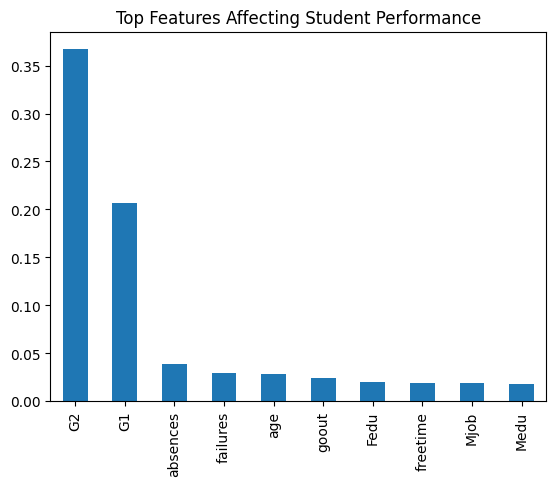

                 Model  Accuracy  Precision    Recall  F1 Score  \
0  Logistic Regression  0.949367       0.98  0.942308  0.960784   
1        Random Forest  0.898734       0.94  0.903846  0.921569   

   Cross Validation Score  
0                0.908861  
1                0.908861  


In [ ]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ==============================
# 2. Load Dataset
# ==============================
df = pd.read_csv("student-mat.csv", sep=";")

print(df.head())
print(df.info())

# ==============================
# 3. Exploratory Data Analysis
# ==============================

# Summary statistics
print(df.describe())

# Study time vs final grade
plt.figure()
sns.boxplot(x=df["studytime"], y=df["G3"])
plt.title("Study Time vs Final Grade")
plt.show()

# Absences vs final grade
plt.figure()
sns.scatterplot(x=df["absences"], y=df["G3"])
plt.title("Absences vs Final Grade")
plt.show()

# Correlation heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# ==============================
# 4. Feature Preparation
# ==============================

# Create Pass/Fail column
df["pass"] = df["G3"].apply(lambda x: 1 if x >= 10 else 0)

# Encode categorical variables
df_encoded = df.copy()

label = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = label.fit_transform(df_encoded[col])

# ==============================
# 5. Clustering (Learning Profiles)
# ==============================

cluster_features = df_encoded[[
    "studytime",
    "absences",
    "failures",
    "G1",
    "G2"
]]

# Scale data
scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(cluster_scaled)

print(df["cluster"].value_counts())

# ==============================
# 6. Label Clusters
# ==============================

cluster_profile = df.groupby("cluster")[[
    "studytime","absences","failures","G3"
]].mean()

print(cluster_profile)

# Example interpretation
cluster_labels = {
    0: "Consistent Learners",
    1: "Irregular Learners",
    2: "Struggling Students"
}

df["learning_profile"] = df["cluster"].map(cluster_labels)

print(df[["cluster","learning_profile"]].head())

# ==============================
# 7. Supervised Learning
# ==============================

X = df_encoded.drop(["G3","pass"], axis=1)
y = df_encoded["pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 8. Logistic Regression
# ==============================

log_model = LogisticRegression(max_iter=2000)

log_model.fit(X_train, y_train)

pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, pred_log))

print(classification_report(y_test, pred_log))

# Cross Validation
log_cv = cross_val_score(log_model, X, y, cv=5)

print("Logistic Regression CV Accuracy:", log_cv.mean())

# ==============================
# 9. Random Forest
# ==============================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:")
print(accuracy_score(y_test, pred_rf))

print(classification_report(y_test, pred_rf))

# Cross Validation
rf_cv = cross_val_score(rf_model, X, y, cv=5)

print("Random Forest CV Accuracy:", rf_cv.mean())

# ==============================
# 10. Feature Importance
# ==============================

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure()
importances.head(10).plot(kind='bar')
plt.title("Top Features Affecting Student Performance")
plt.show()

# ==============================
# Model Comparison Table
# ==============================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression metrics
log_accuracy = accuracy_score(y_test, pred_log)
log_precision = precision_score(y_test, pred_log)
log_recall = recall_score(y_test, pred_log)
log_f1 = f1_score(y_test, pred_log)

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, pred_rf)
rf_precision = precision_score(y_test, pred_rf)
rf_recall = recall_score(y_test, pred_rf)
rf_f1 = f1_score(y_test, pred_rf)

# Create comparison table
comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [log_accuracy, rf_accuracy],
    "Precision": [log_precision, rf_precision],
    "Recall": [log_recall, rf_recall],
    "F1 Score": [log_f1, rf_f1],
    "Cross Validation Score": [log_cv.mean(), rf_cv.mean()]
})

print(comparison_table)
